<a href="https://colab.research.google.com/github/lisagamilton/python_for_data_analysis/blob/main/matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

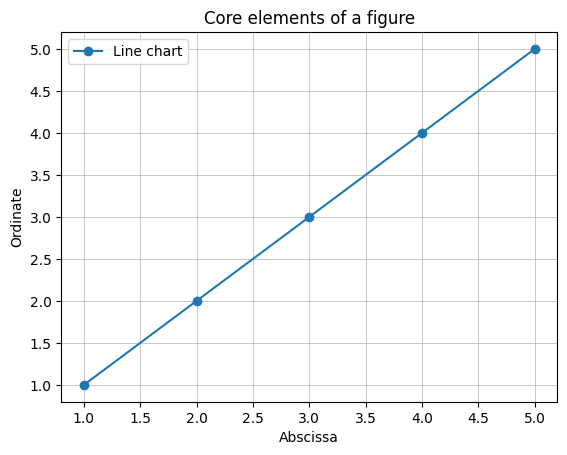

In [ ]:
#Sample data and plot
x = [1,2,3,4,5]
y = [1,2,3,4,5]

fig, ax = plt.subplots()

plt.plot(x,y,label = 'Line chart', marker = 'o')

#Adding labels to axis
plt.xlabel('Abscissa')
plt.ylabel('Ordinate')

#Adding title
plt.title('Core elements of a figure')

#Grid line width
ax.grid(which = 'major',linewidth=0.5)
ax.grid(which = 'minor', linewidth=0.1)

#ax.minorticks_on()
#ax.set_yticks([0,50,100,150,200])

plt.legend()
plt.show()

Text(0.5, 1.0, 'Change of fruits quantity over time')

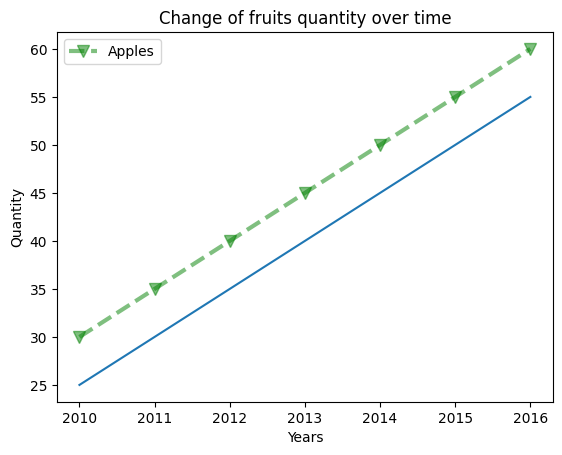

In [ ]:
#Fruits data over time
years = [2010,2011,2012,2013,2014,2015,2016]
apples = [30, 35, 40, 45, 50, 55, 60]
pears = [25, 30, 35, 40, 45, 50, 55]

#Line chart
plt.plot(years,apples, marker = 'v', markersize = 8,
         linestyle = '--', label='Apples', linewidth = 3,
         color='green', alpha=0.5) #alpha is transparency index
plt.plot(years, pears)

#Legend
plt.legend()

#Adding labels
plt.xlabel('Years')
plt.ylabel('Quantity')

plt.title('Change of fruits quantity over time')

In [ ]:
plt.style.available
plt.style.use(['ggplot'])

Text(0.5, 1.0, 'Fruits quantity')

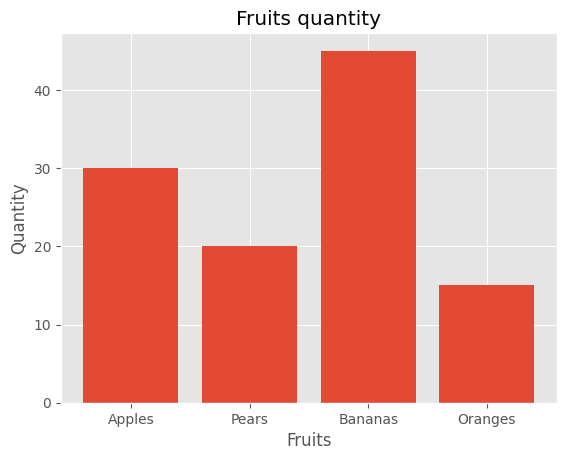

In [ ]:
#barplot
fruits = ['Apples','Pears','Bananas','Oranges']
quantity = [30,20,45,15]

plt.bar(fruits, quantity)
plt.xlabel('Fruits')
plt.ylabel("Quantity")

plt.title("Fruits quantity")

Text(0.5, 1.0, 'The relationship between fruit weight and price')

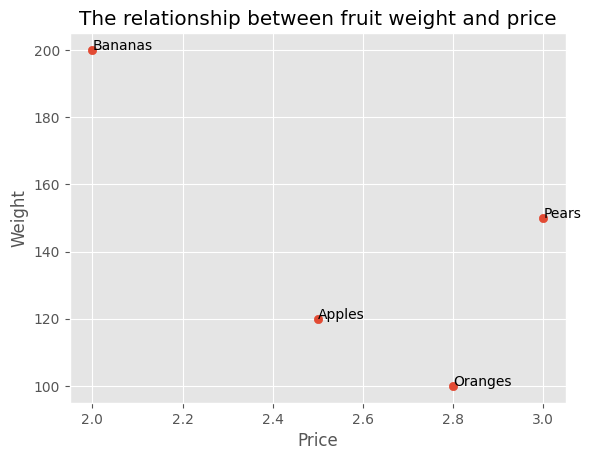

In [ ]:
fruits = ['Apples','Pears','Bananas','Oranges']
weights = [120,150,200,100]
prices = [2.5,3.0,2.0,2.8]

plt.scatter(prices,weights)

plt.xlabel('Price')
plt.ylabel('Weight')

#Adding fruit names to the visual
for i in range(len(fruits)):
  plt.text(prices[i],weights[i],fruits[i])

plt.title('The relationship between fruit weight and price')

In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

In [ ]:
credentials = service_account.Credentials.from_service_account_file('/content/credentials.json')
project_id = 'my-project-26-01-2026'
client = bigquery.Client(credentials = credentials, project=project_id)
query_text = f"""SELECT * FROM `my-project-26-01-2026.dataset1.customer_shopping_data`;"""
query = client.query(query_text)
customer_shopping_data = query.to_dataframe()
customer_shopping_data

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,None,None,%male,10,None,<NA>,NaN,None,NaT,None
1,None,None,mal%e,10,None,<NA>,NaN,None,NaT,None
2,None,None,mal%e,10,None,<NA>,NaN,None,NaT,None
3,None,None,%male,10,None,<NA>,NaN,None,NaT,None
4,None,None,ma%le,20,None,<NA>,NaN,None,NaT,None
...,...,...,...,...,...,...,...,...,...,...
99460,I171509,C211473,Female,69,Souvenir,4,46.92,Cash,2021-09-28,Metropol AVM
99461,I162435,C201383,Female,69,Souvenir,4,46.92,Cash,2021-10-11,Viaport Outlet
99462,I131011,C568057,Female,69,Souvenir,4,46.92,Credit Card,2022-11-24,Mall of Istanbul
99463,I241010,C252866,Male,69,Souvenir,4,46.92,Cash,2021-11-28,Istinye Park


In [ ]:
customer_shopping_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99465 entries, 0 to 99464
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99465 non-null  object 
 3   age             99465 non-null  Int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  Int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  dbdate 
 9   shopping_mall   99457 non-null  object 
dtypes: Int64(2), dbdate(1), float64(1), object(6)
memory usage: 7.8+ MB


In [ ]:
customer_shopping_data['invoice_date'] = pd.to_datetime(customer_shopping_data['invoice_date'])

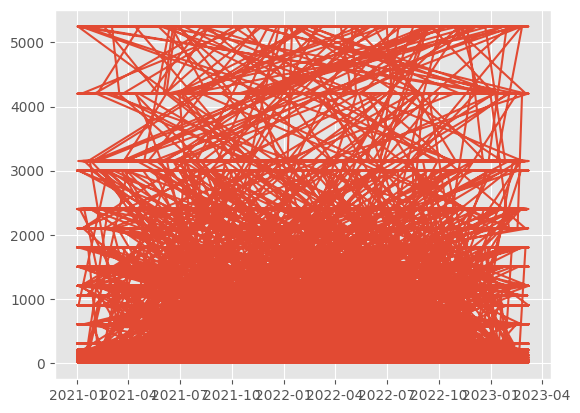

In [ ]:
fig, ax = plt.subplots()
ax.plot(customer_shopping_data['invoice_date'],customer_shopping_data['price'])

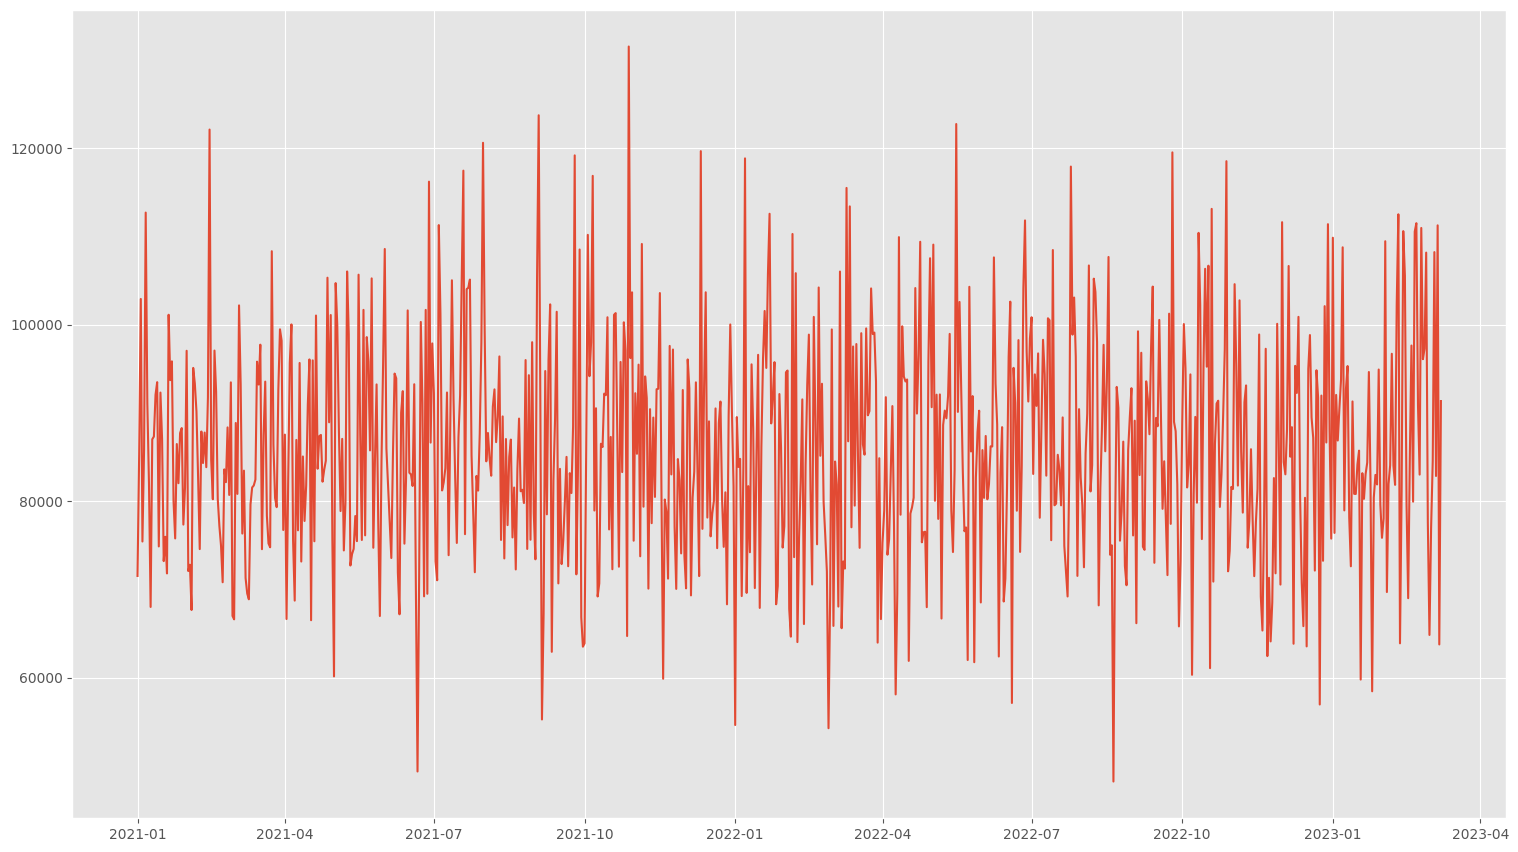

In [ ]:
# its needed to aggregate data
fig, ax = plt.subplots()
fig.set_size_inches(18.5,10.5)
by_date = customer_shopping_data.groupby('invoice_date').agg({'price':'sum','customer_id':'count'})
by_date = by_date.reset_index()
ax.plot(by_date['invoice_date'],by_date['price'])

/tmp/ipykernel_603/2138394139.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  by_date = customer_shopping_data.groupby(pd.Grouper(key='invoice_date',freq='M')).agg({'price':'sum','customer_id':'count'})


Text(0, 0.5, 'Total Amount')

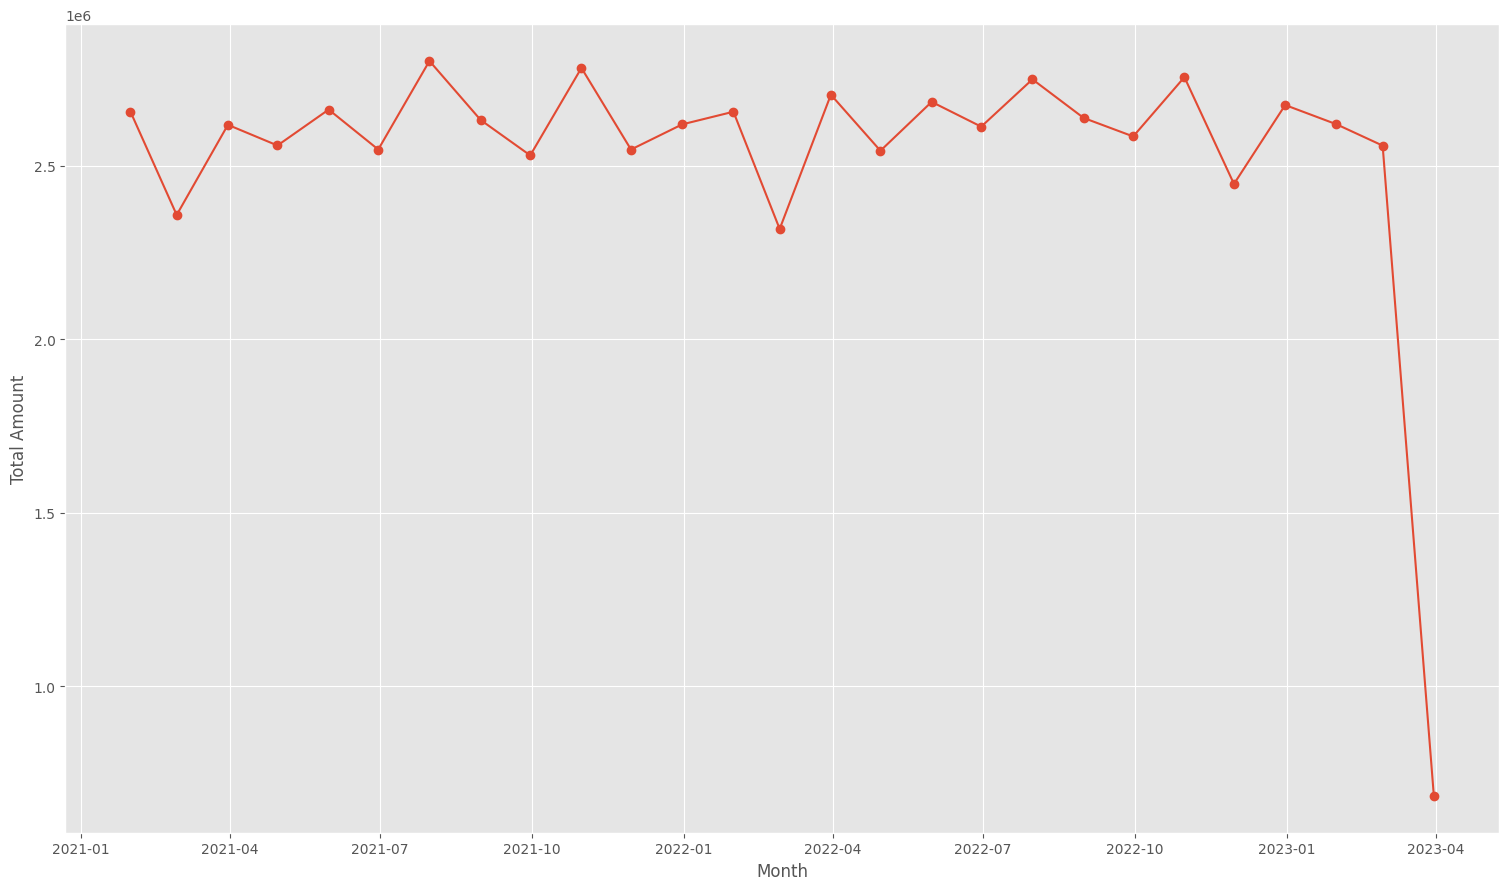

In [ ]:
#Grouping by MONTH
by_date = customer_shopping_data.groupby(pd.Grouper(key='invoice_date',freq='M')).agg({'price':'sum','customer_id':'count'})
by_date = by_date.reset_index()
by_date.rename(columns={'price':'total_amount','customer_id':'customers'},inplace=True)
fig, ax = plt.subplots()
fig.set_size_inches(18.5,10.5)
ax.plot(by_date['invoice_date'],by_date['total_amount'], marker='o')
plt.xlabel('Month')
plt.ylabel('Total Amount')


<BarContainer object of 12 artists>

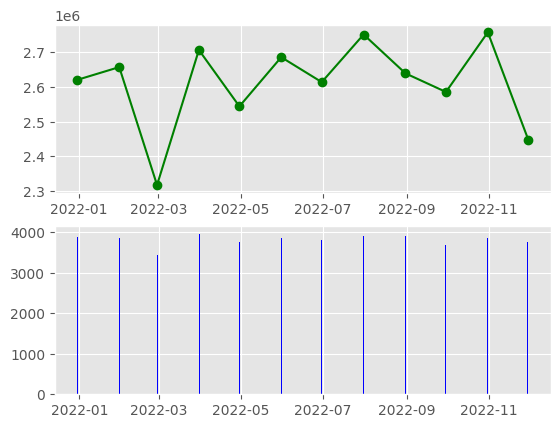

In [ ]:
fig, ax = plt.subplots(2,1)
#filtering to 2022
by_date = by_date[(by_date['invoice_date'] > '2021-12-01') & (by_date['invoice_date'] < '2022-12-01')]

ax[0].plot(by_date['invoice_date'], by_date['total_amount'],marker='o',color='green')
ax[1].bar(by_date['invoice_date'], by_date['customers'],color = 'blue')

<BarContainer object of 12 artists>

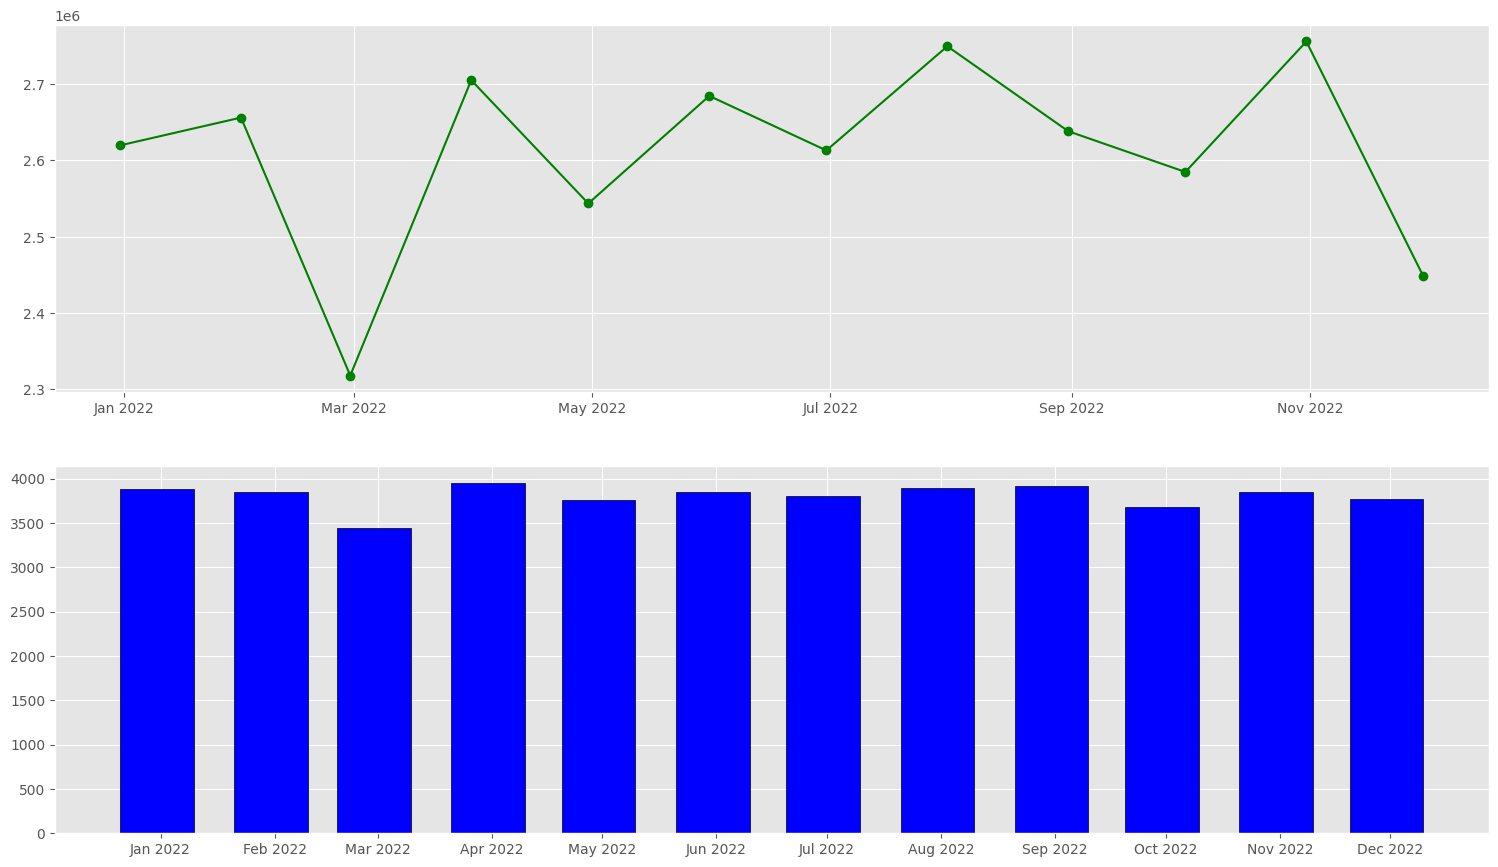

In [ ]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(2,1)
fig.set_size_inches(18.5,10.5)
#filtering to 2022
by_date = by_date[(by_date['invoice_date'] > '2021-12-01') & (by_date['invoice_date'] < '2022-12-01')]

#Format for dates on x axis
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax[1].xaxis.set_major_locator(mdates.MonthLocator())

#Format for dates on x axis
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].plot(by_date['invoice_date'],by_date['total_amount'], marker='o',color='green')
ax[1].bar(by_date['invoice_date'],by_date['customers'],width=20,edgecolor='black',color='blue')

Text(0.5, 1.0, 'Shopping Mall by total amount')

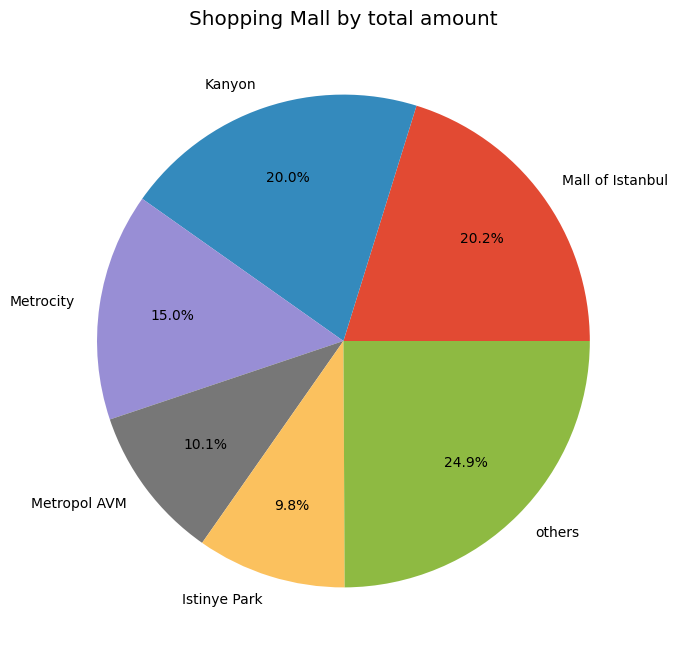

In [ ]:
fig, ax = plt.subplots(1,figsize=(10,8))

#adding group by by shops
by_shop = customer_shopping_data.groupby('shopping_mall').agg({'price':'sum',
                                                               'customer_id':'count'})
by_shop = by_shop.reset_index()
by_shop.rename(columns = {'price':'total_amount','customer_id':'customers'},inplace=True)
by_shop = by_shop.sort_values('total_amount',ascending=False)

#the top 5
by_shop_groupped = by_shop[:5].copy()

#others
by_shop_groupped_new_row = pd.DataFrame(data = {
    'shopping_mall':['others'],
    'total_amount':[by_shop['total_amount'][5:].sum()],
    'customers':[by_shop['customers'][5:].sum()]
})

#combining top 5 with others
by_shop_groupped = pd.concat([by_shop_groupped, by_shop_groupped_new_row])
by_shop_groupped

ax.pie(by_shop_groupped['total_amount'],labels = by_shop_groupped['shopping_mall'],autopct='%1.1f%%', pctdistance=0.7,radius=1)
ax.set_title('Shopping Mall by total amount')

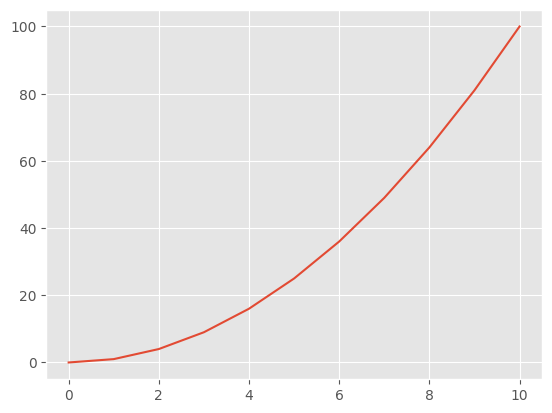

In [ ]:
x = range(0, 11)
y = [i**2 for i in x]

fig, ax = plt.subplots()
ax.plot(x,y)

Text(0.5, 1.0, 'Temperature change within hourse')

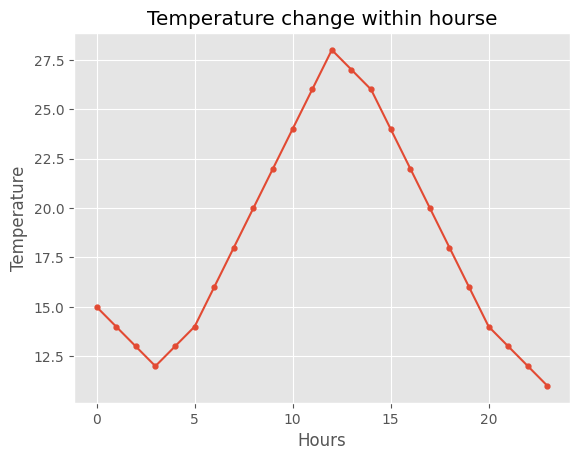

In [ ]:
hours = range(0, 24)
temperature = [15, 14, 13, 12, 13, 14, 16, 18, 20, 22, 24, 26, 28, 27, 26, 24, 22, 20, 18, 16, 14, 13, 12, 11]
fig, ax = plt.subplots()
ax.plot(hours, temperature, marker = 'o', ms=3.5)
plt.xlabel('Hours')
plt.ylabel('Temperature')
plt.title('Temperature change within hourse')

Text(0, 0.5, 'Quantity')

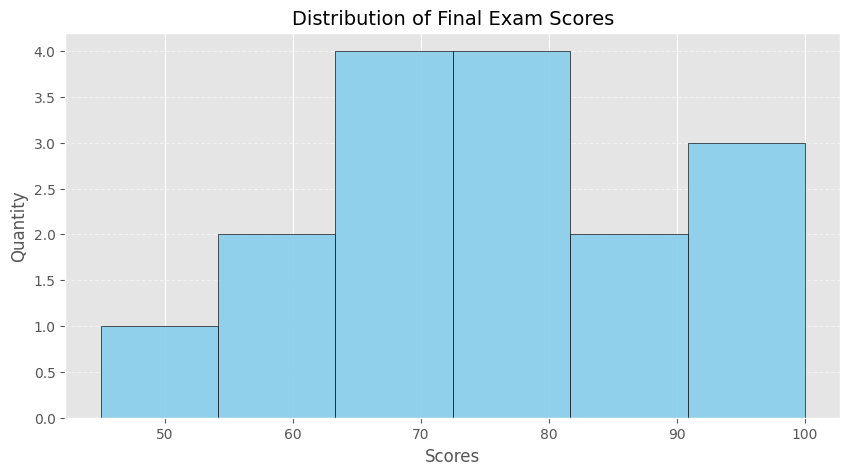

In [ ]:
final_exam_scores = [45, 55, 60, 65, 70, 72, 78, 80, 85, 90, 95, 98, 100, 66, 73, 77]
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(final_exam_scores, bins=6, color='skyblue', edgecolor='black', alpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_title('Distribution of Final Exam Scores', fontsize=14)
ax.set_xlabel('Scores')
ax.set_ylabel('Quantity')

([<matplotlib.patches.Wedge at 0x7cc8de984a10>,
 [Text(0.6465637011386807, 0.8899187493079641, 'Харчування'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'Житло'),
  Text(0.3399193389948208, -1.0461619582919865, 'Транспорт'),
  Text(1.046162345950534, -0.33991814590467956, 'Розваги')])

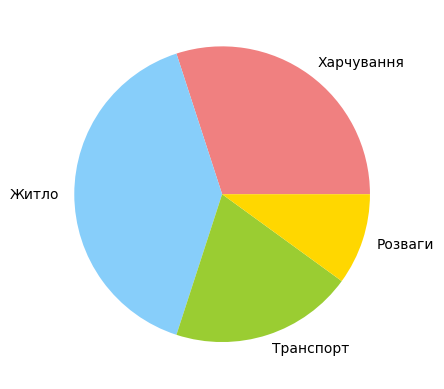

In [ ]:
categories = ['Харчування', 'Житло', 'Транспорт', 'Розваги']
expenses = [30, 40, 20, 10]
colors = ['lightcoral', 'lightskyblue', 'yellowgreen', 'gold']

fig, ax = plt.subplots()
ax.pie(expenses, labels=categories, colors = colors)

([<matplotlib.patches.Wedge at 0x7cc8dfdbbe60>,
 [Text(0.33991865722907993, 1.0461621798113232, 'Facebook'),
  Text(-1.0461620947148778, -0.33991891912892863, 'Instagram'),
  Text(0.3399193389948208, -1.0461619582919865, 'Twitter'),
  Text(1.046162345950534, -0.33991814590467956, 'LinkedIn')],
 [Text(0.18541017667040724, 0.5706339162607217, '40.0%'),
  Text(-0.5706338698444787, -0.18541031952487017, '30.0%'),
  Text(0.1854105485426295, -0.5706337954319927, '20.0%'),
  Text(0.5706340068821094, -0.18540989776618885, '10.0%')])

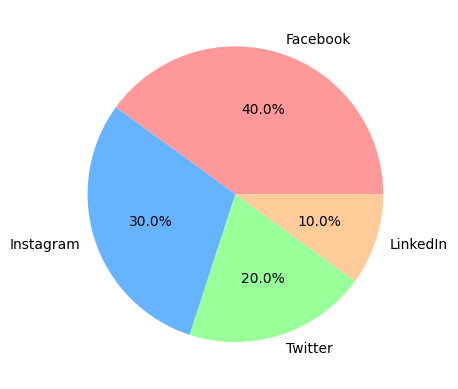

In [ ]:
social_media = ['Facebook', 'Instagram', 'Twitter', 'LinkedIn']
usage = [40, 30, 20, 10]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

fig, ax = plt.subplots()
ax.pie(usage, labels = social_media, colors = colors, autopct='%1.1f%%')

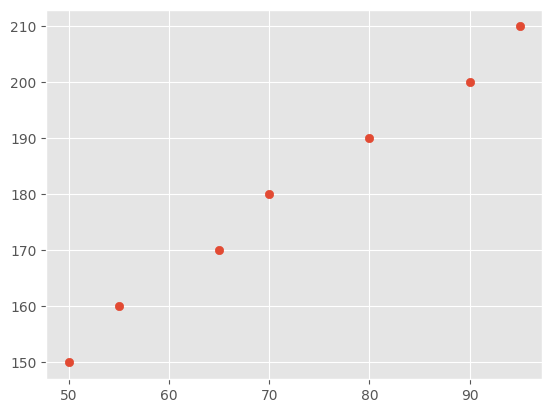

In [ ]:
height = [150, 160, 170, 180, 190, 200, 210]
weight = [50, 55, 65, 70, 80, 90, 95]

fig, ax = plt.subplots()
ax.scatter(weight, height)

Text(0, 0.5, 'Sales')

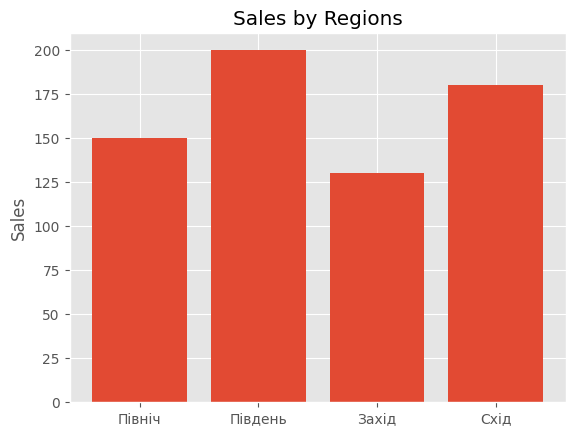

In [ ]:
regions = ['Північ', 'Південь', 'Захід', 'Схід']
sales = [150, 200, 130, 180]

fig, ax = plt.subplots()
ax.bar(regions, sales)
plt.title('Sales by Regions')
plt.ylabel('Sales')

Text(0, 0.5, 'Users')

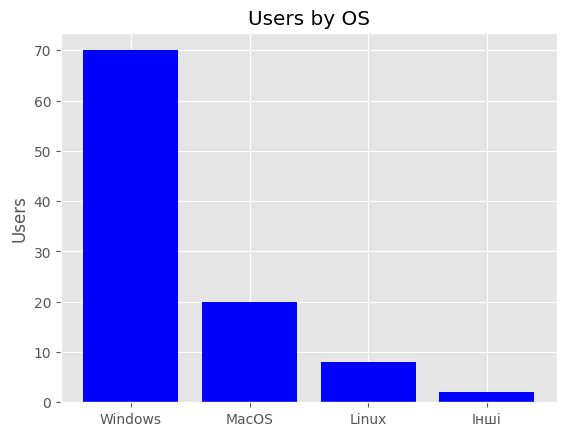

In [ ]:
os = ['Windows', 'MacOS', 'Linux', 'Інші']
users = [70, 20, 8, 2]

fig,ax = plt.subplots()
ax.bar(os, users, color = 'blue')
plt.title('Users by OS')
plt.ylabel('Users')